In [1]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

In [2]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [3]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [4]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

In [5]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [6]:
# Download kaggle dataset and unzip the file
# !cp kaggle.json ~/.kaggle/

# !chmod 600 ~/.kaggle/kaggle.json
#!/bin/bash
!kaggle datasets download jtiptj/chest-xray-pneumoniacovid19tuberculosis
!unzip chest-xray-pneumoniacovid19tuberculosis.zip -d chest_xray

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0843-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0845-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0846-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0847-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0848-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0849-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0851-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0851-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0851-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0852-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0853-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0854-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0855-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL2-IM-0856-0001.jpeg  
  inflating: chest_xray/train

In [7]:
import os
import shutil

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Direktori awal untuk train dan test
train_dir = "chest_xray/train"
test_dir = "chest_xray/test"

# Direktori baru untuk dataset gabungan
combined_dir = "chest_xray/dataset"

# Buat direktori baru untuk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

In [8]:
# Salin file dan folder dari train
for category in os.listdir(train_dir):
    category_dir = os.path.join(train_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari test
for category in os.listdir(test_dir):
    category_dir = os.path.join(test_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

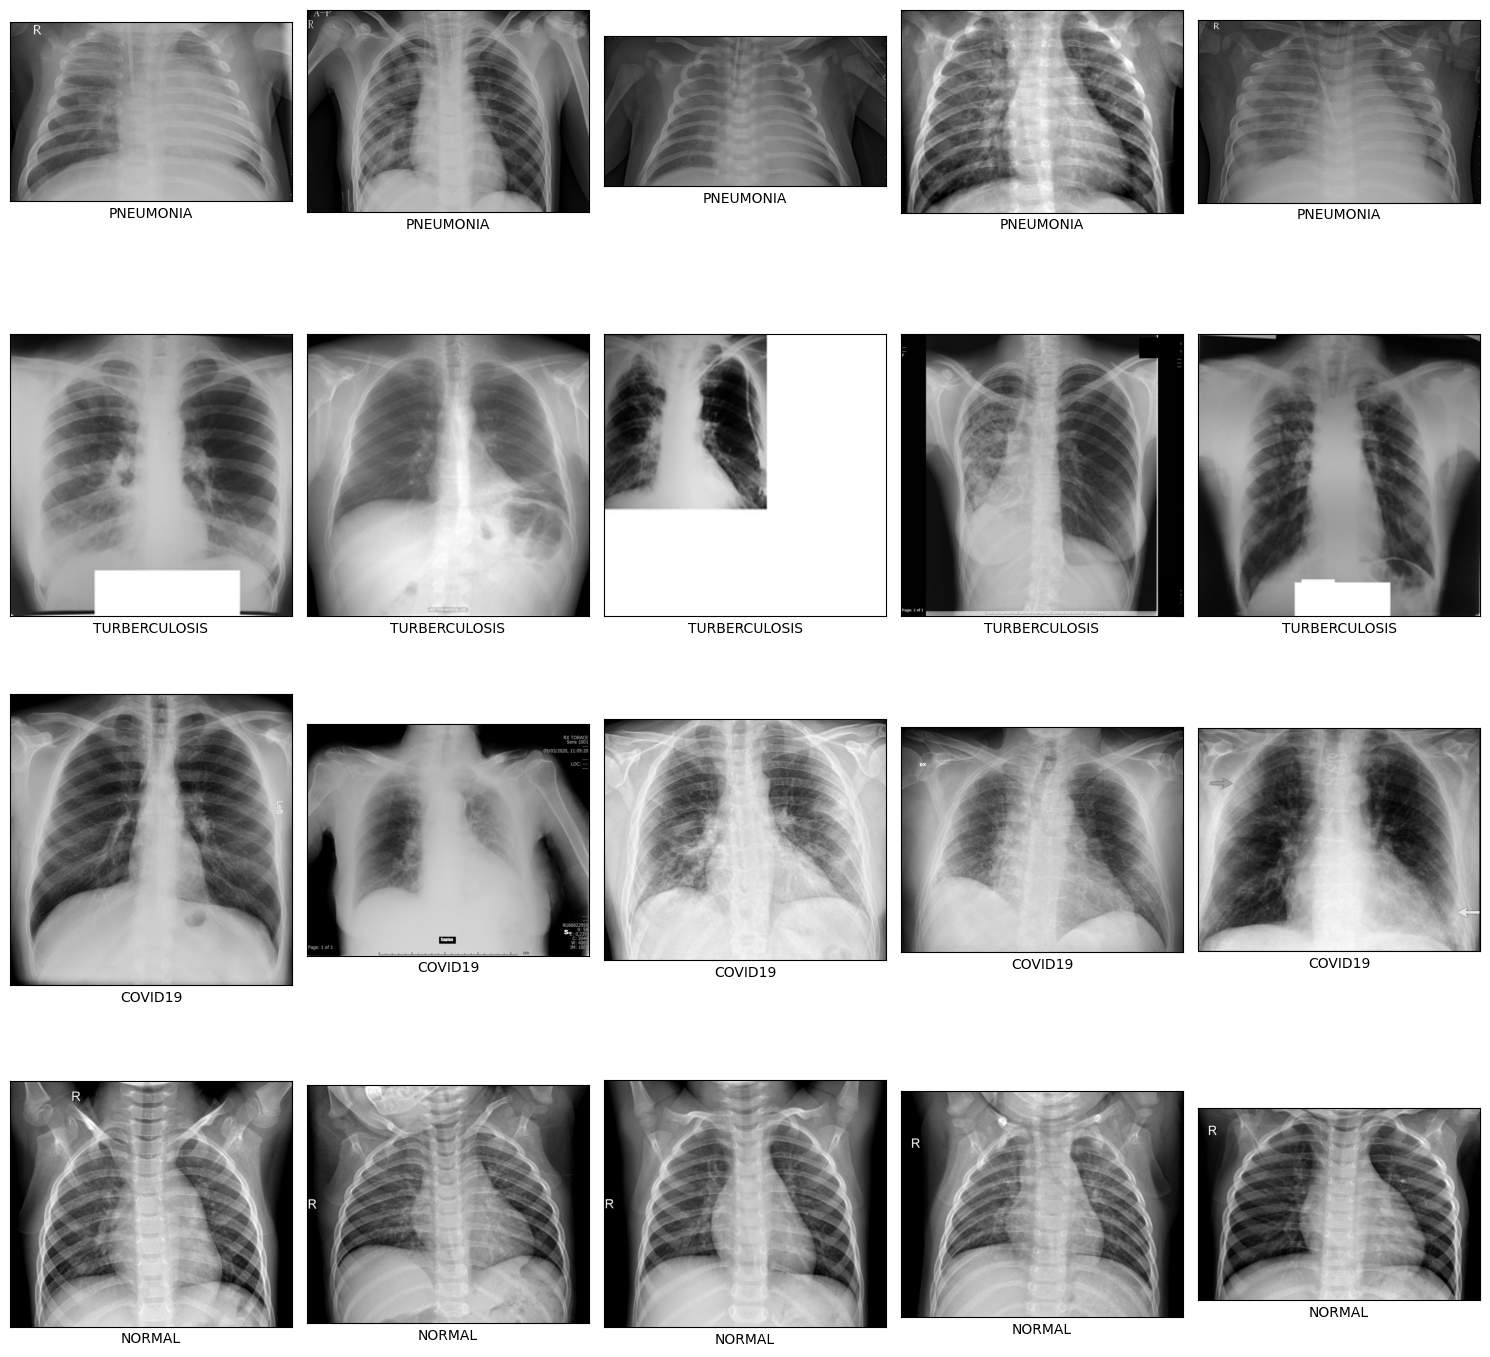

In [9]:
# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
lung_image = {}

# Tentukan path sumber train
path = "chest_xray/"
path_sub = os.path.join(path, "dataset")
for i in os.listdir(path_sub):
    lung_image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap dari 2 kelas dari data.
# Anda akan melihat gambar yang berbeda setiap kali kode ini dijalankan.
path_sub = "chest_xray/dataset/"

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(lung_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(lung_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("L")  # Konversi menjadi skala keabuan
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

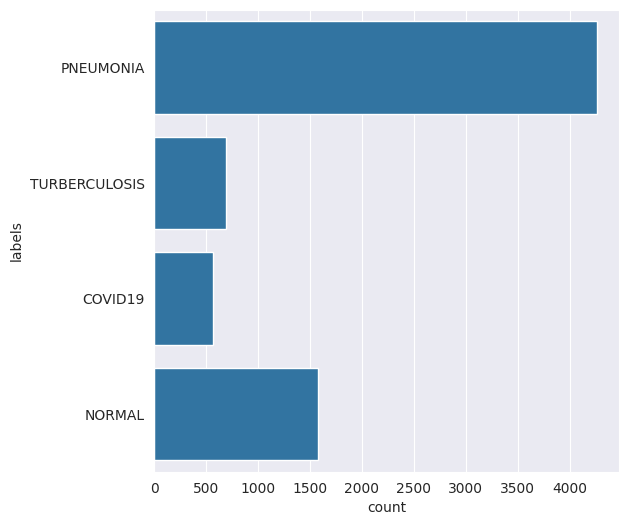

In [10]:
# Definisikan path sumber
lung_path = "chest_xray/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [11]:
# Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    sudut = random.randint(0,180)
    return rotate(img, sudut)

# Membuat fungsi untuk melakukan rotasi searah jarum jam
def clockwise_rotation(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    sudut = random.randint(0,180)
    return rotate(img, -sudut)

# Membuat fungsi untuk membalik gambar secara vertikal dari atas ke bawah
def flip_up_down(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    return np.flipud(img)

# Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    img = adjust_gamma(img, gamma=0.5,gain=1)
    return img

# Membuat fungsi untuk memberikan efek blur pada gambar
def blur_image(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    return cv2.GaussianBlur(img, (9,9),0)

# Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(shear=0.2)
    shear_image = warp(img, transform, mode="wrap")
    return shear_image

# Membuat fungsi untuk melakukan pergeseran melengkung pada gambar
def warp_shift(img):
    img = cv2.cvtColor(img, 0)
    img = cv2.resize(img, (224,224))
    transform = AffineTransform(translation=(0,40))
    warp_image = warp(img, transform, mode="wrap")
    return warp_image

In [12]:
# Membuat variabel transformasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'warp shift': warp_shift,
                    'blurring image': blur_image,
                    'add brightness' : add_brightness,
                    'flip up down': flip_up_down,
                    'shear image': sheared
                  }

images_path="chest_xray/dataset/NORMAL" # Path untuk gambar asli
augmented_path="chest_xray/dataset/NORMAL" # Path untuk gambar yang sudah diaugmentasi
images=[] # Penyimpanan gambar yang telah melalui pra-pemrosesan

# Baca nama gambar dari folder dan tambahkan path ke dalam array "images"
for im in os.listdir(images_path):
    images.append(os.path.join(images_path,im))

# Jumlah gambar yang akan ditambahkan dengan hasil transformasi augmentasi, jumlahnya disesuaikan sesuai kebutuhan
# Variabel untuk melakukan iterasi sampai jumlah gambar yang ditentukan dalam images_to_generate
images_to_generate=2700
i=1

while i<=images_to_generate:
    image=random.choice(images)
    try:
        original_image = io.imread(image)
        transformed_image=None
        n = 0      # Variabel untuk melakukan iterasi sampai jumlah transformasi yang akan diterapkan
        transformation_count = random.randint(1, len(transformations)) # Pilih jumlah transformasi acak yang akan diterapkan pada gambar

        while n <= transformation_count:
            key = random.choice(list(transformations)) # Secara acak memilih dan memanggil metode
            transformed_image = transformations[key](original_image)
            n = n + 1

        new_image_path= "%s/augmented_image_%s.jpg" %(augmented_path, i)
        transformed_image = img_as_ubyte(transformed_image)  # Mengonversi gambar ke format byte yang tidak ditandatangani, dengan nilai dalam [0, 255]
        cv2.imwrite(new_image_path, transformed_image)  # Simpan hasil transformasi augmentasi pada gambar ke path yang ditentukan
        i =i+1
    except ValueError as e:
        print('could not read the',image ,':',e,'hence skipping it.')

In [13]:
# Membuat variabel transformasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'warp shift': warp_shift,
                    'blurring image': blur_image,
                    'add brightness' : add_brightness,
                    'flip up down': flip_up_down,
                    'shear image': sheared
                  }

images_path="chest_xray/dataset/COVID19" # Path untuk gambar asli
augmented_path="chest_xray/dataset/COVID19" # Path untuk gambar yang sudah diaugmentasi
images=[] # Penyimpanan gambar yang telah melalui pra-pemrosesan

# Baca nama gambar dari folder dan tambahkan path ke dalam array "images"
for im in os.listdir(images_path):
    images.append(os.path.join(images_path,im))

# Jumlah gambar yang akan ditambahkan dengan hasil transformasi augmentasi, jumlahnya disesuaikan sesuai kebutuhan
# Variabel untuk melakukan iterasi sampai jumlah gambar yang ditentukan dalam images_to_generate
images_to_generate=3750
i=1

while i<=images_to_generate:
    image=random.choice(images)
    try:
        original_image = io.imread(image)
        transformed_image=None
        n = 0      # Variabel untuk melakukan iterasi sampai jumlah transformasi yang akan diterapkan
        transformation_count = random.randint(1, len(transformations)) # Pilih jumlah transformasi acak yang akan diterapkan pada gambar

        while n <= transformation_count:
            key = random.choice(list(transformations)) # Secara acak memilih dan memanggil metode
            transformed_image = transformations[key](original_image)
            n = n + 1

        new_image_path= "%s/augmented_image_%s.jpg" %(augmented_path, i)
        transformed_image = img_as_ubyte(transformed_image)  # Mengonversi gambar ke format byte yang tidak ditandatangani, dengan nilai dalam [0, 255]
        cv2.imwrite(new_image_path, transformed_image)  # Simpan hasil transformasi augmentasi pada gambar ke path yang ditentukan
        i =i+1
    except ValueError as e:
        print('could not read the',image ,':',e,'hence skipping it.')

In [14]:
# Membuat variabel transformasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'warp shift': warp_shift,
                    'blurring image': blur_image,
                    'add brightness' : add_brightness,
                    'flip up down': flip_up_down,
                    'shear image': sheared
                  }

images_path="chest_xray/dataset/TURBERCULOSIS" # Path untuk gambar asli
augmented_path="chest_xray/dataset/TURBERCULOSIS" # Path untuk gambar yang sudah diaugmentasi
images=[] # Penyimpanan gambar yang telah melalui pra-pemrosesan

# Baca nama gambar dari folder dan tambahkan path ke dalam array "images"
for im in os.listdir(images_path):
    images.append(os.path.join(images_path,im))

# Jumlah gambar yang akan ditambahkan dengan hasil transformasi augmentasi, jumlahnya disesuaikan sesuai kebutuhan
# Variabel untuk melakukan iterasi sampai jumlah gambar yang ditentukan dalam images_to_generate
images_to_generate=3600
i=1

while i<=images_to_generate:
    image=random.choice(images)
    try:
        original_image = io.imread(image)
        transformed_image=None
        n = 0      # Variabel untuk melakukan iterasi sampai jumlah transformasi yang akan diterapkan
        transformation_count = random.randint(1, len(transformations)) # Pilih jumlah transformasi acak yang akan diterapkan pada gambar

        while n <= transformation_count:
            key = random.choice(list(transformations)) # Secara acak memilih dan memanggil metode
            transformed_image = transformations[key](original_image)
            n = n + 1

        new_image_path= "%s/augmented_image_%s.jpg" %(augmented_path, i)
        transformed_image = img_as_ubyte(transformed_image)  # Mengonversi gambar ke format byte yang tidak ditandatangani, dengan nilai dalam [0, 255]
        cv2.imwrite(new_image_path, transformed_image)  # Simpan hasil transformasi augmentasi pada gambar ke path yang ditentukan
        i =i+1
    except ValueError as e:
        print('could not read the',image ,':',e,'hence skipping it.')

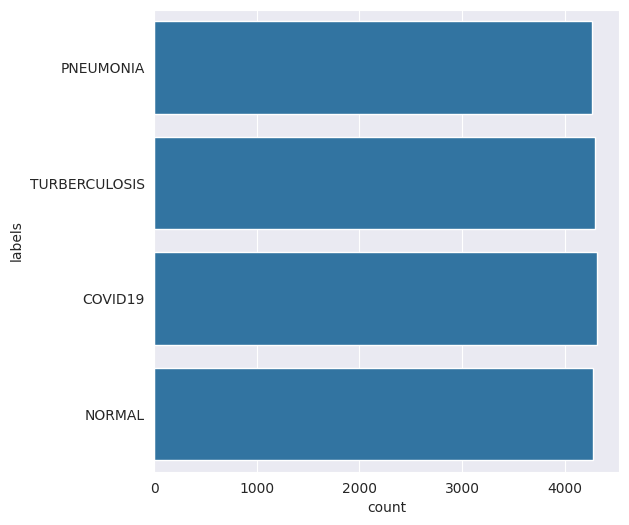

In [15]:
# Definisikan path sumber
lung_path = "chest_xray/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [16]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= 'chest_xray/dataset/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
COVID19,4316
NORMAL,4275
PNEUMONIA,4265
TURBERCULOSIS,4291


In [17]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels

X= df['path']
y= df['labels']

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [18]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})
df_val = pd.DataFrame({'path':X_val,'labels':y_val,'set':'val'})

In [19]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te, df_val], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "chest_xray/dataset/"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"


set    labels       
test   COVID19           432
       NORMAL            428
       PNEUMONIA         426
       TURBERCULOSIS     429
train  COVID19          3452
       NORMAL           3420
       PNEUMONIA        3412
       TURBERCULOSIS    3433
val    COVID19           432
       NORMAL            427
       PNEUMONIA         427
       TURBERCULOSIS     429
dtype: int64 


                                                    path         labels    set
3368         chest_xray/dataset/COVID19/COVID19(111).jpg        COVID19  train
13594  chest_xray/dataset/COVID19/augmented_image_326...        COVID19  train
8273   chest_xray/dataset/TURBERCULOSIS/augmented_ima...  TURBERCULOSIS  train
1081   chest_xray/dataset/NORMAL/augmented_image_2020...         NORMAL  train
990    chest_xray/dataset/PNEUMONIA/person649_bacteri...      PNEUMONIA  train


In [20]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

In [21]:
# Definisikan direktori training dan test
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"
VAL_DIR = "Dataset-Final/val/"

train_normal = os.path.join(TRAIN_DIR + '/NORMAL')
train_pneumonia = os.path.join(TRAIN_DIR + '/PNEUMONIA')
train_covid19 = os.path.join(TRAIN_DIR + '/COVID19')
train_turberculosis = os.path.join(TRAIN_DIR + '/TURBERCULOSIS')

test_normal = os.path.join(TEST_DIR + '/NORMAL')
test_pneumonia = os.path.join(TEST_DIR + '/PNEUMONIA')
test_covid19 = os.path.join(TEST_DIR + '/COVID19')
test_turberculosis = os.path.join(TEST_DIR + '/TURBERCULOSIS')

val_normal = os.path.join(VAL_DIR + '/NORMAL')
val_pneumonia = os.path.join(VAL_DIR + '/PNEUMONIA')
val_covid19 = os.path.join(VAL_DIR + '/COVID19')
val_turberculosis = os.path.join(VAL_DIR + '/TURBERCULOSIS')

print("Total number of normal images in training set: ",len(os.listdir(train_normal)))
print("Total number of pneumonic images in training set: ",len(os.listdir(train_pneumonia)))
print("Total number of covid19 images in training set: ",len(os.listdir(train_covid19)))
print("Total number of turberculosis images in training set: ",len(os.listdir(train_turberculosis)))

print("Total number of normal images in test set: ",len(os.listdir(test_normal)))
print("Total number of pneumonic images in test set: ",len(os.listdir(test_pneumonia)))
print("Total number of covid19 images in test set: ",len(os.listdir(test_covid19)))
print("Total number of turberculosis images in test set: ",len(os.listdir(test_turberculosis)))

print("Total number of normal images in test set: ",len(os.listdir(val_normal)))
print("Total number of pneumonic images in test set: ",len(os.listdir(val_pneumonia)))
print("Total number of covid19 images in test set: ",len(os.listdir(val_covid19)))
print("Total number of turberculosis images in test set: ",len(os.listdir(val_turberculosis)))

Total number of normal images in training set:  3420
Total number of pneumonic images in training set:  3412
Total number of covid19 images in training set:  3452
Total number of turberculosis images in training set:  3433
Total number of normal images in test set:  428
Total number of pneumonic images in test set:  426
Total number of covid19 images in test set:  432
Total number of turberculosis images in test set:  429
Total number of normal images in test set:  427
Total number of pneumonic images in test set:  427
Total number of covid19 images in test set:  432
Total number of turberculosis images in test set:  429


In [22]:
# Buat objek ImageDataGenerator yang menormalkan gambar
datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=32,
                                              target_size=(150,150),
                                              color_mode="grayscale",
                                              class_mode='categorical',
                                              shuffle=True)

validation_generator = datagen.flow_from_directory(VAL_DIR,
                                                   batch_size=32,
                                                   target_size=(150,150),
                                                   color_mode="grayscale",
                                                   class_mode='categorical',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=32,
                                                  target_size=(150,150),
                                                  color_mode="grayscale",
                                                  class_mode='categorical',
                                                  shuffle=False)

Found 13717 images belonging to 4 classes.
Found 1715 images belonging to 4 classes.
Found 1715 images belonging to 4 classes.


In [23]:
from tensorflow.keras.layers import Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

tf.keras.backend.clear_session()

model_1 = Sequential()

model_1.add(Conv2D(16, (3, 3), padding='same', use_bias=False,
                   kernel_regularizer=l2(0.001), input_shape=(150,150,1)))
model_1.add(BatchNormalization())
model_1.add(Activation('relu'))
model_1.add(MaxPool2D((2, 2)))

model_1.add(Conv2D(32, (3, 3), padding='same', use_bias=False,
                   kernel_regularizer=l2(0.001)))
model_1.add(BatchNormalization())
model_1.add(Activation('relu'))
model_1.add(MaxPool2D((2, 2)))

model_1.add(Conv2D(64, (3, 3), padding='same', use_bias=False,
                   kernel_regularizer=l2(0.001)))
model_1.add(BatchNormalization())
model_1.add(Activation('relu'))
model_1.add(MaxPool2D((2, 2)))

model_1.add(GlobalAveragePooling2D())
model_1.add(Dropout(0.3))

model_1.add(Dense(128, kernel_regularizer=l2(0.01)))
model_1.add(BatchNormalization())  # Optional: add BN here too
model_1.add(Activation('relu'))
model_1.add(Dropout(0.5))

model_1.add(Dense(64, kernel_regularizer=l2(0.01)))
model_1.add(BatchNormalization())  # Optional: add BN here too
model_1.add(Activation('relu'))
model_1.add(Dropout(0.3))

model_1.add(Dense(4, activation='softmax'))

model_1.compile(optimizer=Adam(learning_rate=0.001),
                loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
                metrics=['accuracy'])

print(model_1.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150, 150, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             

 Total params: 41,236 (161.08 KB)

 Trainable params: 40,628 (158.70 KB)

 Non-trainable params: 608 (2.38 KB)

None


In [24]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import numpy as np

classes = np.unique(train_generator.classes)
weights = compute_class_weight('balanced', classes=classes, y=train_generator.classes)
class_weights = dict(enumerate(weights))
print("Class weights:", class_weights)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history_1 = model_1.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=[reduce_lr, early_stop, checkpoint]
)

Class weights: {0: np.float64(0.993409617612978), 1: np.float64(1.002704678362573), 2: np.float64(1.0050556858147714), 3: np.float64(0.9989076609379551)}
Epoch 1/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.4413 - loss: 2.7587
Epoch 1: val_accuracy improved from None to 0.30904, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
429/429 ━━━━━━━━━━━━━━━━━━━━ 84s 172ms/step - accuracy: 0.5449 - loss: 2.2761 - val_accuracy: 0.3090 - val_loss: 2.3264 - learning_rate: 0.0010
Epoch 2/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.7089 - loss: 1.3758
Epoch 2: val_accuracy improved from 0.30904 to 0.61458, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
429/429 ━━━━━━━━━━━━━━━━━━━━ 62s 145ms/step - accuracy: 0.7290 - loss: 1.2440 - val_accuracy: 0.6146 - val_loss: 1.4548 - learning_rate: 0.0010
Epoch 3/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7723 - loss: 0.9856
Epoch 3: val_accuracy did not improve from 0.61458
429/429 ━━━━━━━━━━━━━━━━━━━━ 63s 146ms/step - accuracy: 0.7754 - loss: 0.9486 - val_accuracy: 0.5714 - val_loss: 1.1704 - learning_rate: 0.0010
Epoch 4/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7925 - loss: 0.8662
Epoch 4: val_accuracy improved from 0.61458 to 0.70204, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
429/429 ━━━━━━━━━━━━━━━━━━━━ 63s 147ms/step - accuracy: 0.7988 - loss: 0.8501 - val_accuracy: 0.7020 - val_loss: 0.9625 - learning_rate: 0.0010
Epoch 5/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8210 - loss: 0.8065
Epoch 5: val_accuracy improved from 0.70204 to 0.78309, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
429/429 ━━━━━━━━━━━━━━━━━━━━ 66s 153ms/step - accuracy: 0.8183 - loss: 0.8032 - val_accuracy: 0.7831 - val_loss: 0.8615 - learning_rate: 0.0010
Epoch 6/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8191 - loss: 0.7886
Epoch 6: val_accuracy improved from 0.78309 to 0.81691, saving model to best_model.h5


...


Epoch 8: finished saving model to best_model.h5
429/429 ━━━━━━━━━━━━━━━━━━━━ 62s 145ms/step - accuracy: 0.8470 - loss: 0.7359 - val_accuracy: 0.8805 - val_loss: 0.6742 - learning_rate: 0.0010
Epoch 9/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8496 - loss: 0.7173
Epoch 9: val_accuracy did not improve from 0.88047
429/429 ━━━━━━━━━━━━━━━━━━━━ 62s 144ms/step - accuracy: 0.8489 - loss: 0.7217 - val_accuracy: 0.6688 - val_loss: 1.2286 - learning_rate: 0.0010
Epoch 10/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8571 - loss: 0.7199
Epoch 10: val_accuracy did not improve from 0.88047
429/429 ━━━━━━━━━━━━━━━━━━━━ 62s 144ms/step - accuracy: 0.8609 - loss: 0.7123 - val_accuracy: 0.6501 - val_loss: 1.0402 - learning_rate: 0.0010
Epoch 11/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8633 - loss: 0.7059
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 11: val_accuracy did not improve from 0.88047
429/429 ━━━━━━━━━━━━


Epoch 13: finished saving model to best_model.h5
429/429 ━━━━━━━━━━━━━━━━━━━━ 65s 150ms/step - accuracy: 0.8925 - loss: 0.6392 - val_accuracy: 0.9178 - val_loss: 0.5831 - learning_rate: 5.0000e-04
Epoch 14/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8965 - loss: 0.6332
Epoch 14: val_accuracy did not improve from 0.91778
429/429 ━━━━━━━━━━━━━━━━━━━━ 62s 146ms/step - accuracy: 0.8972 - loss: 0.6317 - val_accuracy: 0.8595 - val_loss: 0.6591 - learning_rate: 5.0000e-04
Epoch 15/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8907 - loss: 0.6387
Epoch 15: val_accuracy did not improve from 0.91778
429/429 ━━━━━━━━━━━━━━━━━━━━ 62s 145ms/step - accuracy: 0.8963 - loss: 0.6314 - val_accuracy: 0.8717 - val_loss: 0.6340 - learning_rate: 5.0000e-04
Epoch 16/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9112 - loss: 0.6064
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 16: val_accuracy did not improve from 0.91778
429/4


Epoch 20: finished saving model to best_model.h5
429/429 ━━━━━━━━━━━━━━━━━━━━ 62s 145ms/step - accuracy: 0.9290 - loss: 0.5612 - val_accuracy: 0.9429 - val_loss: 0.5155 - learning_rate: 1.2500e-04
Epoch 21/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9371 - loss: 0.5458
Epoch 21: val_accuracy improved from 0.94286 to 0.95685, saving model to best_model.h5



Epoch 21: finished saving model to best_model.h5
429/429 ━━━━━━━━━━━━━━━━━━━━ 62s 145ms/step - accuracy: 0.9311 - loss: 0.5539 - val_accuracy: 0.9569 - val_loss: 0.4843 - learning_rate: 1.2500e-04
Epoch 22/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9346 - loss: 0.5478
Epoch 22: val_accuracy did not improve from 0.95685
429/429 ━━━━━━━━━━━━━━━━━━━━ 61s 143ms/step - accuracy: 0.9326 - loss: 0.5494 - val_accuracy: 0.9061 - val_loss: 0.5878 - learning_rate: 1.2500e-04
Epoch 23/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9352 - loss: 0.5430
Epoch 23: val_accuracy did not improve from 0.95685
429/429 ━━━━━━━━━━━━━━━━━━━━ 61s 141ms/step - accuracy: 0.9359 - loss: 0.5463 - val_accuracy: 0.9300 - val_loss: 0.5278 - learning_rate: 1.2500e-04
Epoch 24/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9339 - loss: 0.5456
Epoch 24: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 24: val_accuracy did not improve from 0.95685
429/42


Epoch 27: finished saving model to best_model.h5
429/429 ━━━━━━━━━━━━━━━━━━━━ 60s 141ms/step - accuracy: 0.9380 - loss: 0.5376 - val_accuracy: 0.9603 - val_loss: 0.4802 - learning_rate: 6.2500e-05
Epoch 28/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9420 - loss: 0.5287
Epoch 28: val_accuracy did not improve from 0.96035
429/429 ━━━━━━━━━━━━━━━━━━━━ 61s 141ms/step - accuracy: 0.9391 - loss: 0.5335 - val_accuracy: 0.9551 - val_loss: 0.4789 - learning_rate: 6.2500e-05
Epoch 29/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9390 - loss: 0.5271
Epoch 29: val_accuracy did not improve from 0.96035
429/429 ━━━━━━━━━━━━━━━━━━━━ 65s 151ms/step - accuracy: 0.9392 - loss: 0.5287 - val_accuracy: 0.9534 - val_loss: 0.4820 - learning_rate: 6.2500e-05
Epoch 30/30
429/429 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.9423 - loss: 0.5284
Epoch 30: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 30: val_accuracy did not improve from 0.96035
429/4

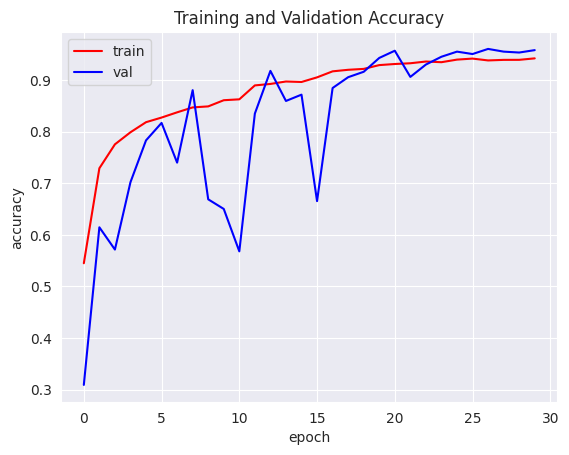

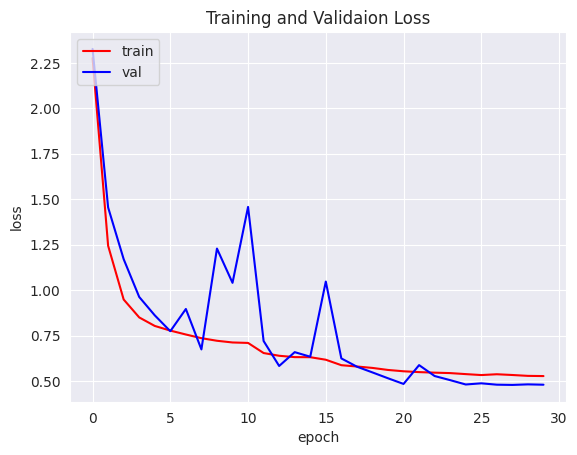

In [25]:
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

Class mapping: {'COVID19': 0, 'NORMAL': 1, 'PNEUMONIA': 2, 'TURBERCULOSIS': 3}


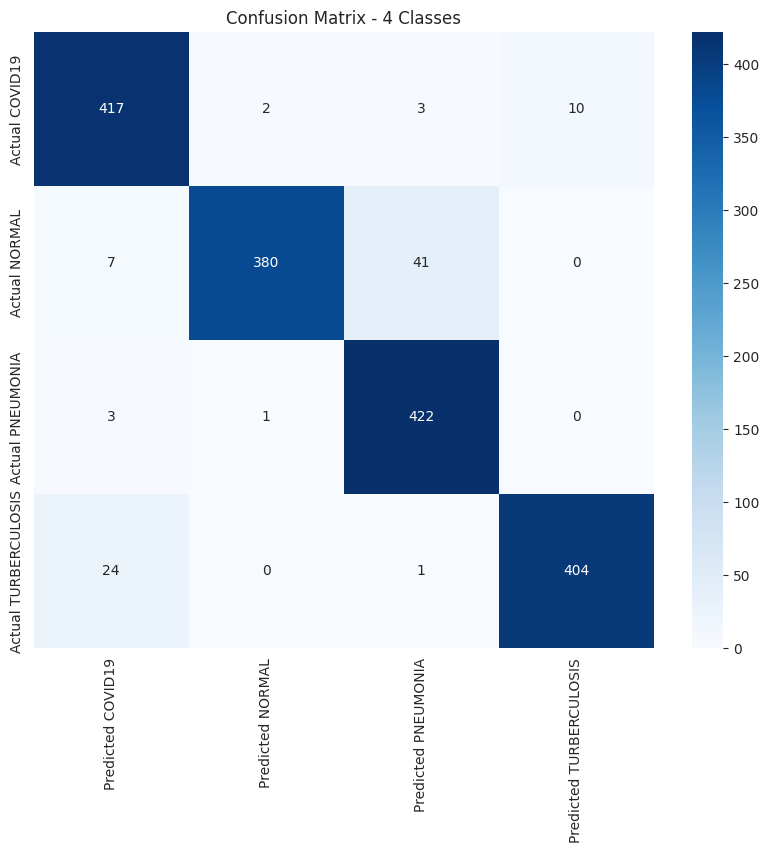


Classification Report:
               precision    recall  f1-score   support

      COVID19     0.9246    0.9653    0.9445       432
       NORMAL     0.9922    0.8879    0.9371       428
    PNEUMONIA     0.9036    0.9906    0.9451       426
TURBERCULOSIS     0.9758    0.9417    0.9585       429

     accuracy                         0.9464      1715
    macro avg     0.9491    0.9464    0.9463      1715
 weighted avg     0.9491    0.9464    0.9463      1715



In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset()

# Get predictions (probabilities for 4 classes)
preds_1 = model_1.predict(test_generator, verbose=0)

# Convert to class indices (0, 1, 2, or 3)
predicted_classes = np.argmax(preds_1, axis=1)

# Get true classes
true_classes = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())
print("Class mapping:", test_generator.class_indices)

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Create DataFrame with proper labels
cm_df = pd.DataFrame(
    data=cm,
    index=[f"Actual {name}" for name in class_names],
    columns=[f"Predicted {name}" for name in class_names]
)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - 4 Classes")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_true=true_classes,
    y_pred=predicted_classes,
    target_names=class_names,
    digits=4
))

In [27]:
# Menyimpan model dalam format SavedModel
export_dir = 'saved_model/'
tf.saved_model.save(model_1, export_dir)

# Convert SavedModel menjadi vegs.tflite
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
tflite_model = converter.convert()

In [28]:
import os
import tensorflow as tf

# Create output folder
OUTPUT_DIR = "tflite"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load trained model
model = tf.keras.models.load_model("best_model.h5")

# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save TFLite model
with open(os.path.join(OUTPUT_DIR, "model.tflite"), "wb") as f:
    f.write(tflite_model)

# Create labels.txt
labels = sorted(
    [folder for folder in os.listdir("Dataset-Final/train")
     if not folder.startswith(".")]
)

with open(os.path.join(OUTPUT_DIR, "labels.txt"), "w") as f:
    for label in labels:
        f.write(label + "\n")

print("Files saved:")
print(f" - {OUTPUT_DIR}/model.tflite")
print(f" - {OUTPUT_DIR}/labels.txt")

Saved artifact at '/tmp/tmp0ro6twbx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139542716996816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139542716997008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139542716992400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139542716993360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139542716990288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139542716995664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139542716992592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139542895253968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139542716993744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139542716993552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139542895260496

In [29]:
# Install tensorflowjs
!pip -q install tensorflowjs

# Convert model.h5 to model
!tensorflowjs_converter --input_format=keras best_model.h5 tfjs_model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
db-dtypes 1.6.0 requires packaging>=24.2.0, but you have packaging 23